# Netflix Movies & TV Shows Analysis using Python

---

# Project Objective

Analyze Netflix content to discover:

- Most common genres
- Ratings distribution
- Country-wise content production
- Movie vs TV Show trends
- Year-wise content growth
- Duration patterns
- Popular content categories

# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# Step 2: Load Dataset

In [5]:
df = pd.read_csv("netflix_titles.csv")

# Step 3: Basic Exploration

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Step 4: Data Cleaning

### Fill Missing Values

In [14]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

### Convert Date Column

In [32]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [33]:
### Fill null values
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

### Extract Year and Month

In [34]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Step 5: Exploratory Data Analysis (EDA)

### 1. Movies vs TV Shows

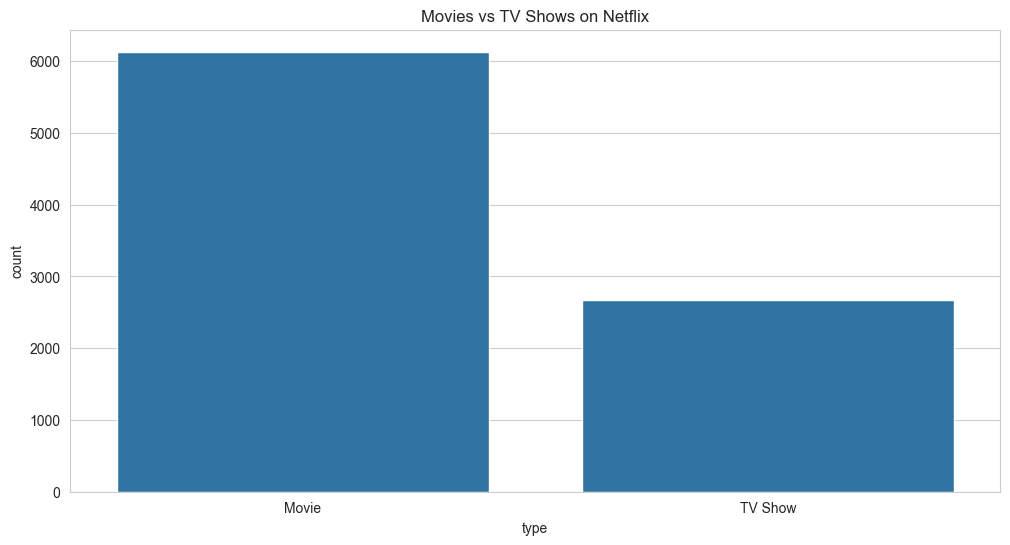

In [37]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

### Insight

- Netflix contains more Movies than TV Shows.

### 2. Content Rating Distribution

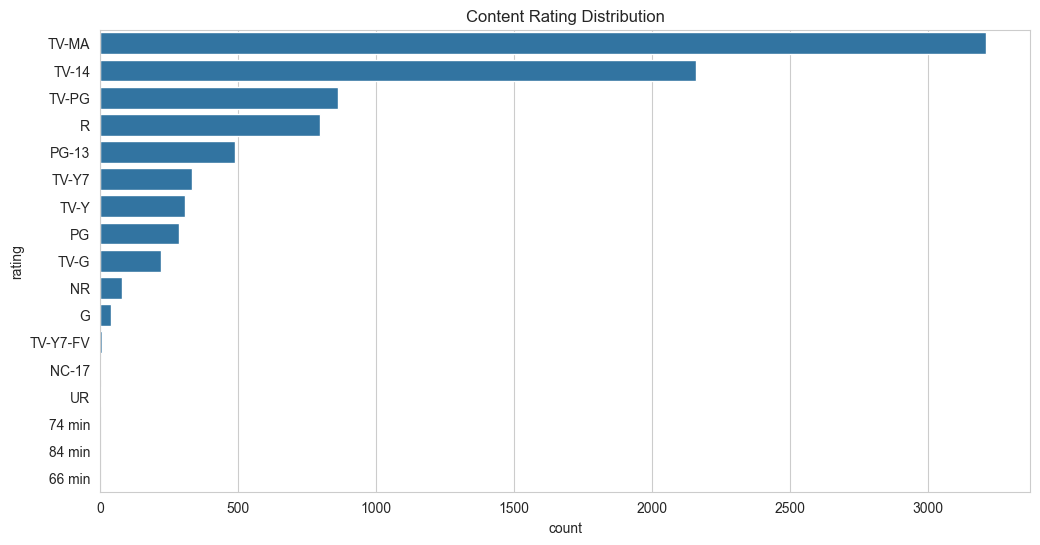

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Content Rating Distribution")
plt.show()

### Insight

- TV-MA and TV-14 are the most common ratings.

### 3. Top 10 Countries Producing Netflix Content

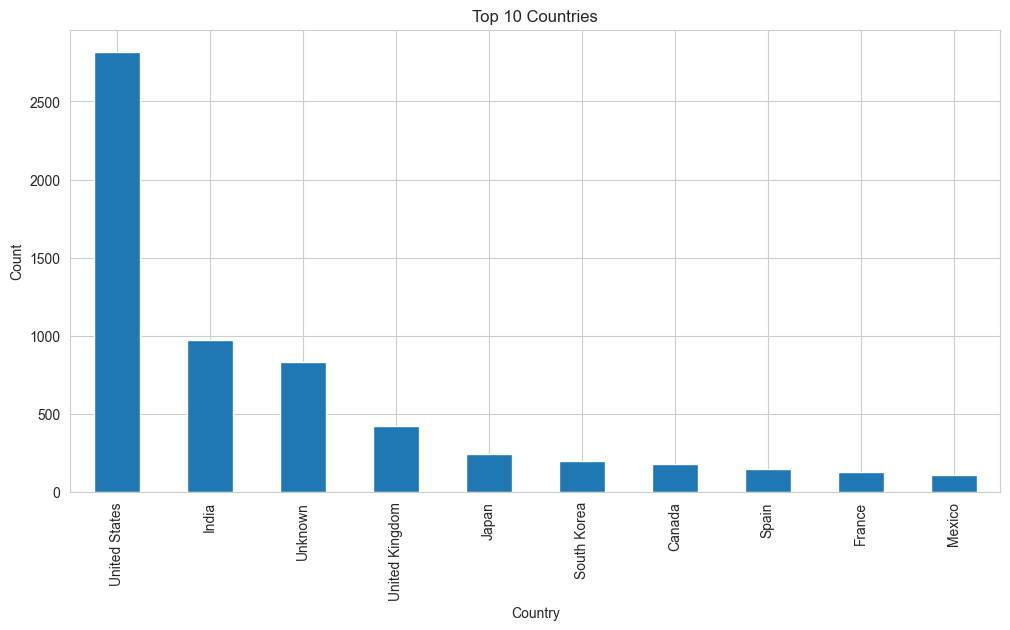

In [39]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

### Insight

- The United States produces the highest amount of Netflix content.

### 4. Content Added Over the Years

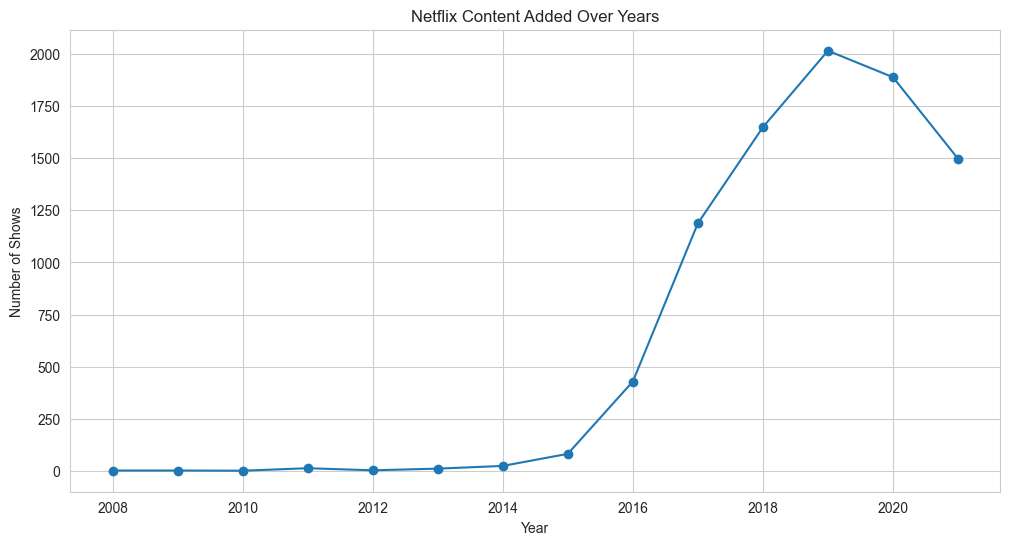

In [42]:
year_data = df['year_added'].value_counts().sort_index()

plt.plot(year_data.index, year_data.values, marker='o')

plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

### Insight

- Netflix content rapidly increased after 2015.

### 5. Top Genres

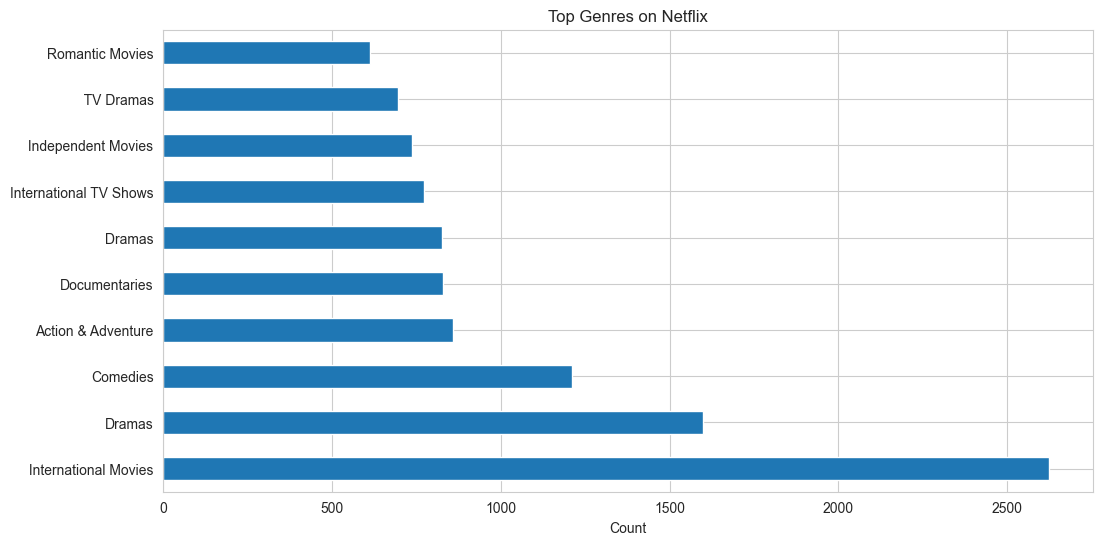

In [43]:
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

top_genres.plot(kind='barh')

plt.title("Top Genres on Netflix")
plt.xlabel("Count")
plt.show()

### Insight

- Drama and International Movies dominate Netflix.

### 6. Pie Chart: Content Type

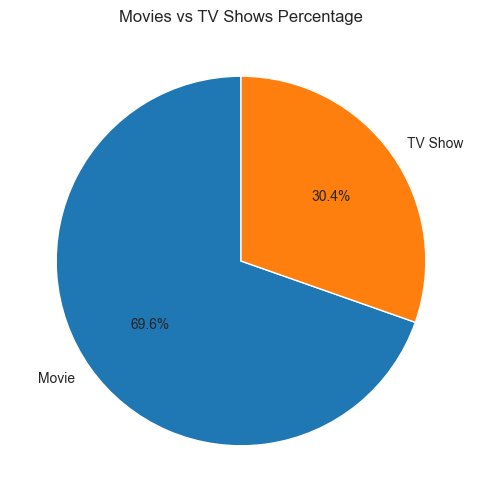

In [44]:
type_counts = df['type'].value_counts()

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Movies vs TV Shows Percentage")
plt.show()

### 7. Distribution Plot of Release Years

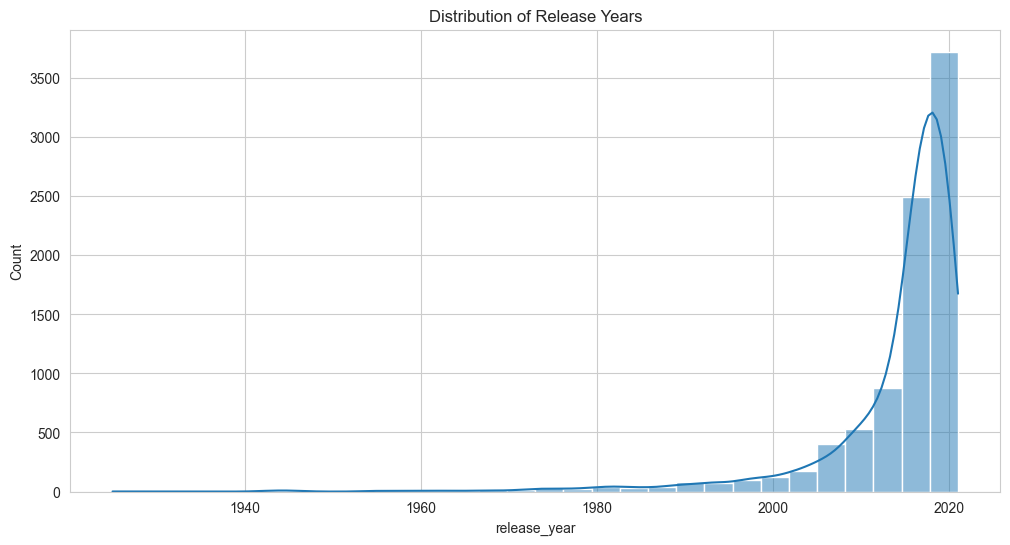

In [46]:
sns.histplot(df['release_year'], bins=30, kde=True)

plt.title("Distribution of Release Years")
plt.show()

### Insight

- Most content was released after 2000.

### 8. Correlation Analysis
- Create Numeric Columns

In [48]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,release_year,year_added,month_added
release_year,1.000000,0.111206,-0.038500
year_added,0.111206,1.000000,-0.161465
month_added,-0.038500,-0.161465,1.000000


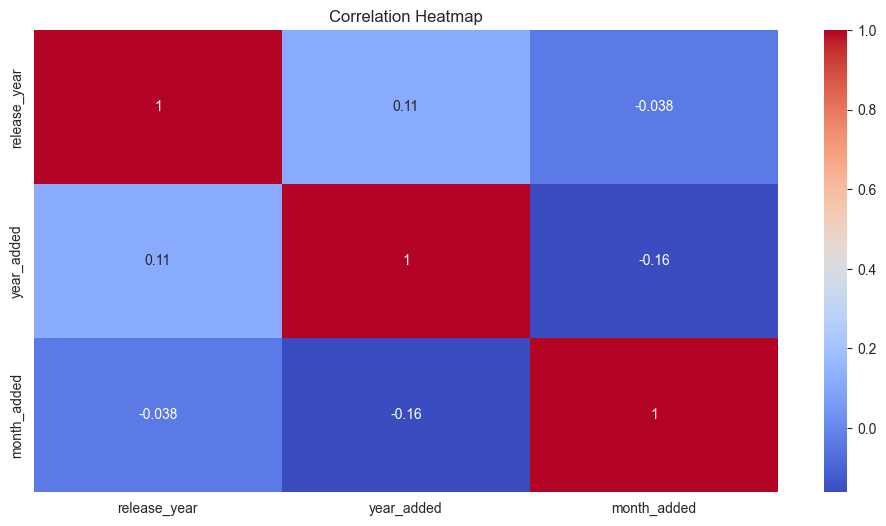

In [49]:
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### 9. Most Common Directors

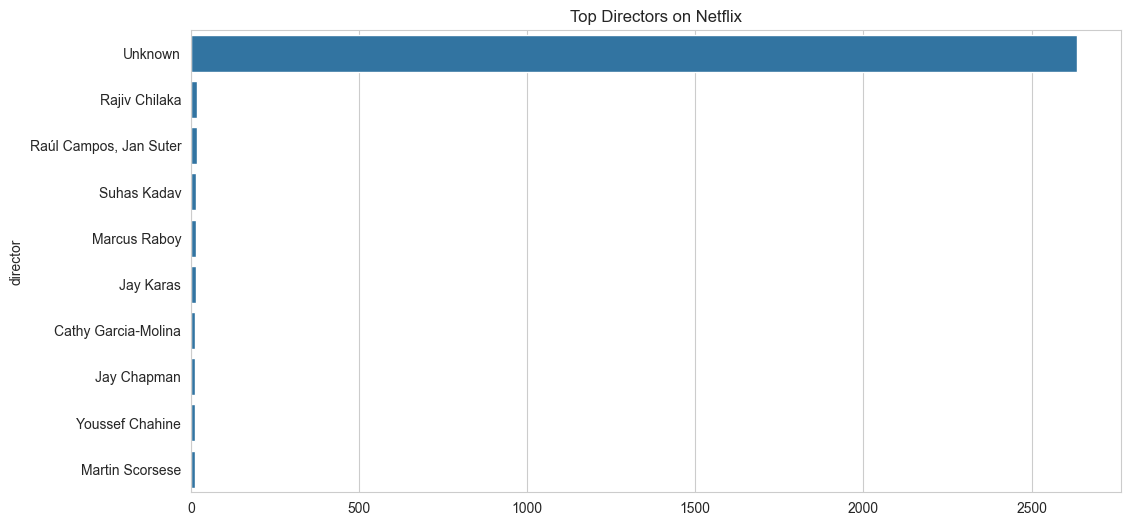

In [50]:
top_directors = df['director'].value_counts().head(10)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top Directors on Netflix")
plt.show()

### 10. Monthly Content Addition

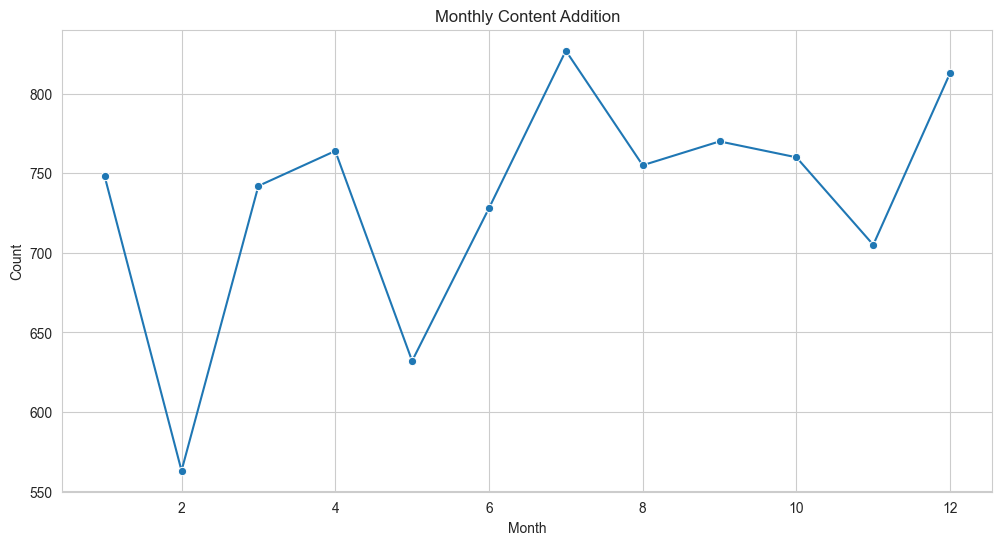

In [51]:
monthly = df['month_added'].value_counts().sort_index()

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker='o'
)

plt.title("Monthly Content Addition")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# Step 6: Advanced Analysis

### Movies Duration Analysis

C:\Users\SANKET\AppData\Local\Temp\ipykernel_14232\3823790793.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_int'] = movies['duration'].str.replace(' min','')
C:\Users\SANKET\AppData\Local\Temp\ipykernel_14232\3823790793.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_int'] = pd.to_numeric(


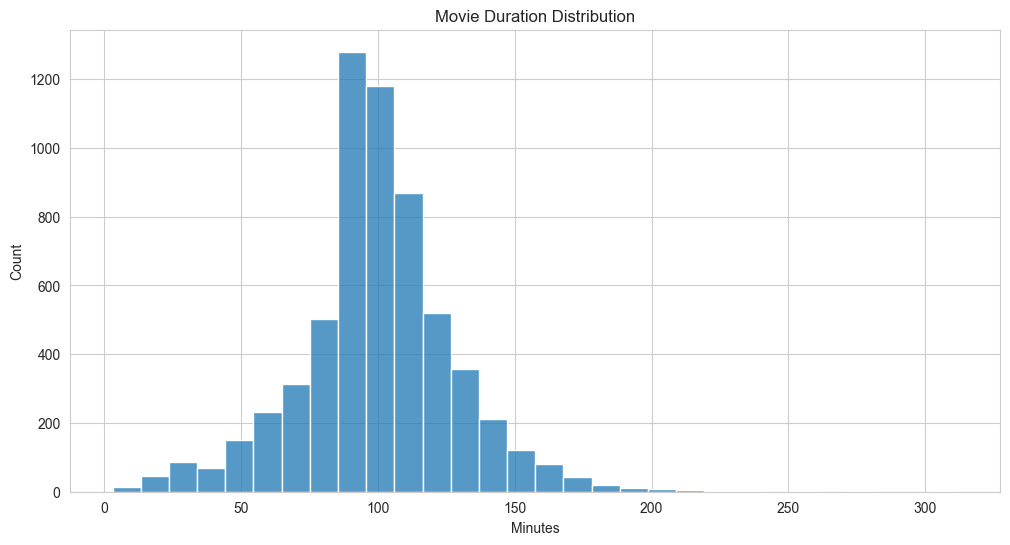

In [52]:
movies = df[df['type'] == 'Movie']

movies['duration_int'] = movies['duration'].str.replace(' min','')

movies['duration_int'] = pd.to_numeric(
    movies['duration_int'],
    errors='coerce'
)

sns.histplot(movies['duration_int'], bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.show()

# Step 7: Key Insights

#### Findings
- Netflix has more Movies than TV Shows.
- TV-MA is the most common rating.
- USA contributes the most content.
- Content growth accelerated after 2015.
- Drama and International genres dominate.
- Most movies are between 80–120 minutes.

# Step 8: Save Cleaned Dataset

In [54]:
df.to_csv("cleaned_netflix_data.csv", index=False)

# Step 9: Export Visualizations

In [55]:
plt.savefig("chart.png")

<Figure size 1200x600 with 0 Axes>